<a href="https://colab.research.google.com/github/Binay-panda19/Deep-Learning/blob/CNN/Plant_Disease_Image_Classification_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Seeding for reproducibility

In [1]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

#Importing the Dependencies

In [2]:
import os
import json

from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

#Data Curation

Upload kaggle json file

In [3]:
!pip install kaggle

In [4]:
# setup Kaggle API key as environment variables
kaggle_credentials = json.load(open('kaggle.json'))
os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']

In [5]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [01:43<00:00, 21.2MB/s]



In [6]:
!ls

kaggle.json  plantvillage-dataset.zip  sample_data


In [7]:
# Unzip the downloaded dataset
with ZipFile('plantvillage-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [8]:
print(os.listdir('plantvillage dataset'))

print(len(os.listdir('plantvillage dataset/segmented')))
print(len(os.listdir('plantvillage dataset/color')))
print(len(os.listdir('plantvillage dataset/grayscale')))

['grayscale', 'color', 'segmented']
38
38
38


Number of Classes  = 38

In [9]:
print(len(os.listdir('plantvillage dataset/color/Grape___healthy')))
print(os.listdir('/content/plantvillage dataset/color/Grape___healthy')[:5])


423
['61a531ba-3d52-4af3-8828-c2dbba4d3b1d___Mt.N.V_HL 8941.JPG', 'c95315d3-0a8f-476e-9eee-c6c9f4246841___Mt.N.V_HL 6197.JPG', '386f8bff-7dbb-42db-80f7-fc36fc226a97___Mt.N.V_HL 8981.JPG', 'ac00a5c9-0af6-4543-866a-ef4c476c3410___Mt.N.V_HL 6110.JPG', 'eaf9de03-6ec6-453b-9cd1-38d5d3337ea3___Mt.N.V_HL 8951.JPG']


# Data Pre-Processing

In [10]:
# dataset path
base = '/content/plantvillage dataset/color/'

(256, 256, 3)


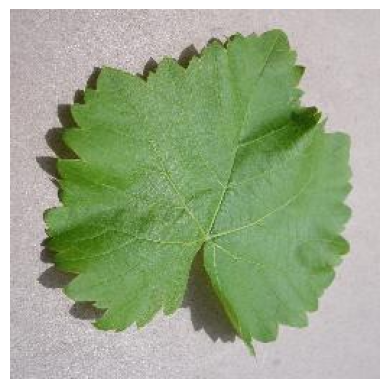

In [11]:
image_path = '/content/plantvillage dataset/color/Grape___healthy/03492a0d-6ad7-42ec-a742-c2f1fa59499a___Mt.N.V_HL 6035.JPG'

# Read the Image
img = mpimg.imread(image_path)

print(img.shape)
# Plot the Image
plt.imshow(img)
plt.axis('off')
plt.show()

In [12]:
# Image parameters
img_size = 224
batch_size = 32

# Train Test Split

In [13]:
# Image Data Generator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 # use 20% of data for validation
)

In [14]:
# Train Generator
train_generator = datagen.flow_from_directory(
    base,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 43456 images belonging to 38 classes.


In [15]:
# Validation Generator
validation_generator = datagen.flow_from_directory(
    base,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 10849 images belonging to 38 classes.


# Convolutional Neural Network - CNN

In [16]:
# Model Definition

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │     3,288,102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,381,350 (12.90 MB)

 Trainable params: 3,381,350 (12.90 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compile the Model
model.compile(optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Model Training

In [19]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size, # Number of steps per epoch
    epochs=5,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size # validation steps
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 103s 70ms/step - accuracy: 0.7661 - loss: 0.8133 - val_accuracy: 0.8821 - val_loss: 0.3717
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 149s 80ms/step - accuracy: 0.9170 - loss: 0.2633 - val_accuracy: 0.8644 - val_loss: 0.4514
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 130s 71ms/step - accuracy: 0.9540 - loss: 0.1446 - val_accuracy: 0.8851 - val_loss: 0.4018
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 95s 70ms/step - accuracy: 0.9713 - loss: 0.0888 - val_accuracy: 0.9039 - val_loss: 0.3800
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 96s 71ms/step - accuracy: 0.9754 - loss: 0.0747 - val_accuracy: 0.8975 - val_loss: 0.4693


#Model Evaluation

In [19]:
print('Evaluating model...')
val_loss, val_acc = model.evaluate(validation_generator, steps=validation_generator // batch_size)
print(f'Validation loss: {val_loss}, Validation accuracy: {val_acc * 100:.2f}')

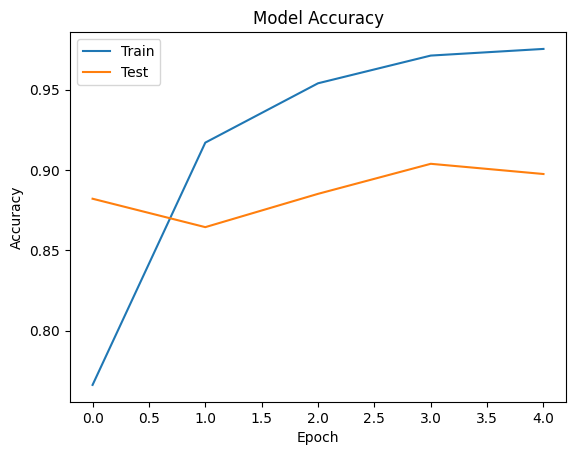

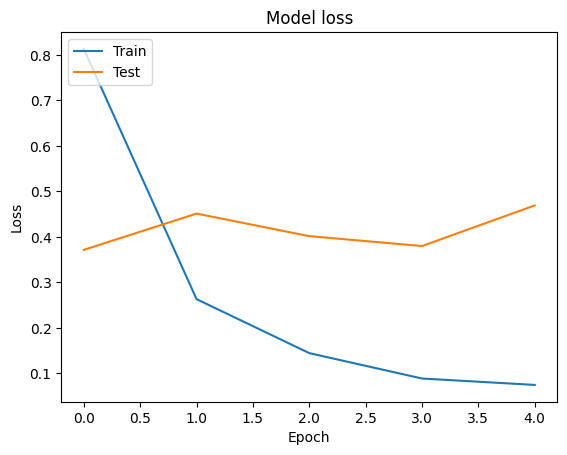

In [22]:
# Plot training and validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()



# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [23]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name


In [25]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [26]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [27]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [ ]:
# Example Usage
image_path = '/content/test_apple_black_rot.JPG'
#image_path = '/content/test_blueberry_healthy.jpg'
#image_path = '/content/test_potato_early_blight.jpg'
predicted_class_name = predict_image_class(model, image_path, class_indices)

# Output the result
print("Predicted Class Name:", predicted_class_name)

In [28]:
model.save('/content/drive/MyDrive/Colab Notebooks/Trained Models/plant_disease_prediction_model.h5')

In [ ]:
model.save('plant_disease_prediction_model.h5')